# Explore MLP Training Data — Input–Output Separability

Loads `friction_dataset.npz` produced by `prepare_data.py` and examines how
well the inputs `(position, velocity, force_realized)` determine the target
`force_sensed`. If many data points share similar inputs but have very different
targets, the MLP will struggle to fit.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.spatial import cKDTree
from scipy.stats import linregress
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [15]:
DATASET_PATH = os.path.join(
    os.path.dirname(os.path.abspath("__file__")), "..",
    "models", "friction", "friction_dataset.npz"
)
DATASET_PATH = os.path.normpath(DATASET_PATH)
print(f"Loading: {DATASET_PATH}")

d = np.load(DATASET_PATH, allow_pickle=True)

position = np.concatenate([d["train_position_um_aligned"],
                           d["val_position_um_aligned"],
                           d["test_position_um_aligned"]])
velocity = np.concatenate([d["train_velocity_mm_s_aligned"],
                           d["val_velocity_mm_s_aligned"],
                           d["test_velocity_mm_s_aligned"]])
f_realized = np.concatenate([d["train_force_mN_realized_aligned"],
                             d["val_force_mN_realized_aligned"],
                             d["test_force_mN_realized_aligned"]])
f_sensed = np.concatenate([d["train_force_mN_sensed_aligned"],
                           d["val_force_mN_sensed_aligned"],
                           d["test_force_mN_sensed_aligned"]])
f_sensed_prev = np.concatenate([d["train_force_mN_sensed_prev"],
                           d["val_force_mN_sensed_prev"],
                           d["test_force_mN_sensed_prev"]])

print(f"Total samples: {len(position):,}")
print(f"Position range:  [{position.min():.0f}, {position.max():.0f}] um")
print(f"Velocity range:  [{velocity.min():.1f}, {velocity.max():.1f}] mm/s")
print(f"F_realized range: [{f_realized.min():.0f}, {f_realized.max():.0f}] mN")
print(f"F_sensed range:   [{f_sensed.min():.0f}, {f_sensed.max():.0f}] mN")
print(f"F_sensed_prev range: [{f_sensed_prev.min():.0f}, {f_sensed_prev.max():.0f}] mN")

Loading: /Users/jazlabamini/Documents/nikashap/orcaSDK_tutorials/models/friction/friction_dataset.npz
Total samples: 3,188,347
Position range:  [10000, 550000] um
Velocity range:  [-4428.9, 11541.3] mm/s
F_realized range: [-36465, 32324] mN
F_sensed range:   [-25393, 25097] mN
F_sensed_prev range: [-25393, 25097] mN


## 1. Neighborhood scatter: F_realized colored by F_sensed

Given a canonical (position, velocity) point and a neighborhood radius,
show all data points in that neighborhood as a scatter of F_realized,
colored by F_sensed.

In [3]:
def plot_neighborhood(canonical_pos_um, canonical_vel_mm_s,
                      pos_radius_um=20000, vel_radius_mm_s=50,
                      ax=None):
    """Plot F_realized colored by F_sensed for data near a canonical point."""
    mask = (
        (np.abs(position - canonical_pos_um) <= pos_radius_um) &
        (np.abs(velocity - canonical_vel_mm_s) <= vel_radius_mm_s)
    )
    n = mask.sum()
    if n == 0:
        print(f"No data within pos={canonical_pos_um}+/-{pos_radius_um} um, "
              f"vel={canonical_vel_mm_s}+/-{vel_radius_mm_s} mm/s")
        return

    fr = f_realized[mask]
    fs = f_sensed[mask]
    pos_local = position[mask]
    vel_local = velocity[mask]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    sc = ax.scatter(fr, fs, c=fs, cmap="coolwarm", s=6, alpha=0.5,
                    edgecolors="none")
    plt.colorbar(sc, ax=ax, label="F_sensed (mN)")

    # reference line: F_sensed = F_realized
    lims = [min(fr.min(), fs.min()), max(fr.max(), fs.max())]
    ax.plot(lims, lims, "k--", alpha=0.3, label="F_sensed = F_realized")

    # linear fit
    if n > 2:
        slope, intercept, r, _, _ = linregress(fr, fs)
        fr_sorted = np.sort(fr)
    #     ax.plot(fr_sorted, slope * fr_sorted + intercept, "r-", alpha=0.7,
    #             label=f"fit: R²={r**2:.3f}, slope={slope:.3f}")

    ax.set_xlabel("F_realized (mN)")
    ax.set_ylabel("F_sensed (mN)")
    ax.set_title(
        f"pos={canonical_pos_um/1000:.0f}mm +/-{pos_radius_um/1000:.0f}mm, "
        f"vel={canonical_vel_mm_s:.0f} +/-{vel_radius_mm_s:.0f} mm/s\n"
        f"({n:,} points, F_sensed std={fs.std():.1f} mN)"
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    return {"n_points": n,
            "f_sensed_std": float(fs.std()),
            "f_sensed_mean": float(fs.mean()),
            "r_squared": float(r**2) if n > 2 else np.nan,
            "residual_std": float(np.std(fs - (slope * fr + intercept))) if n > 2 else np.nan}

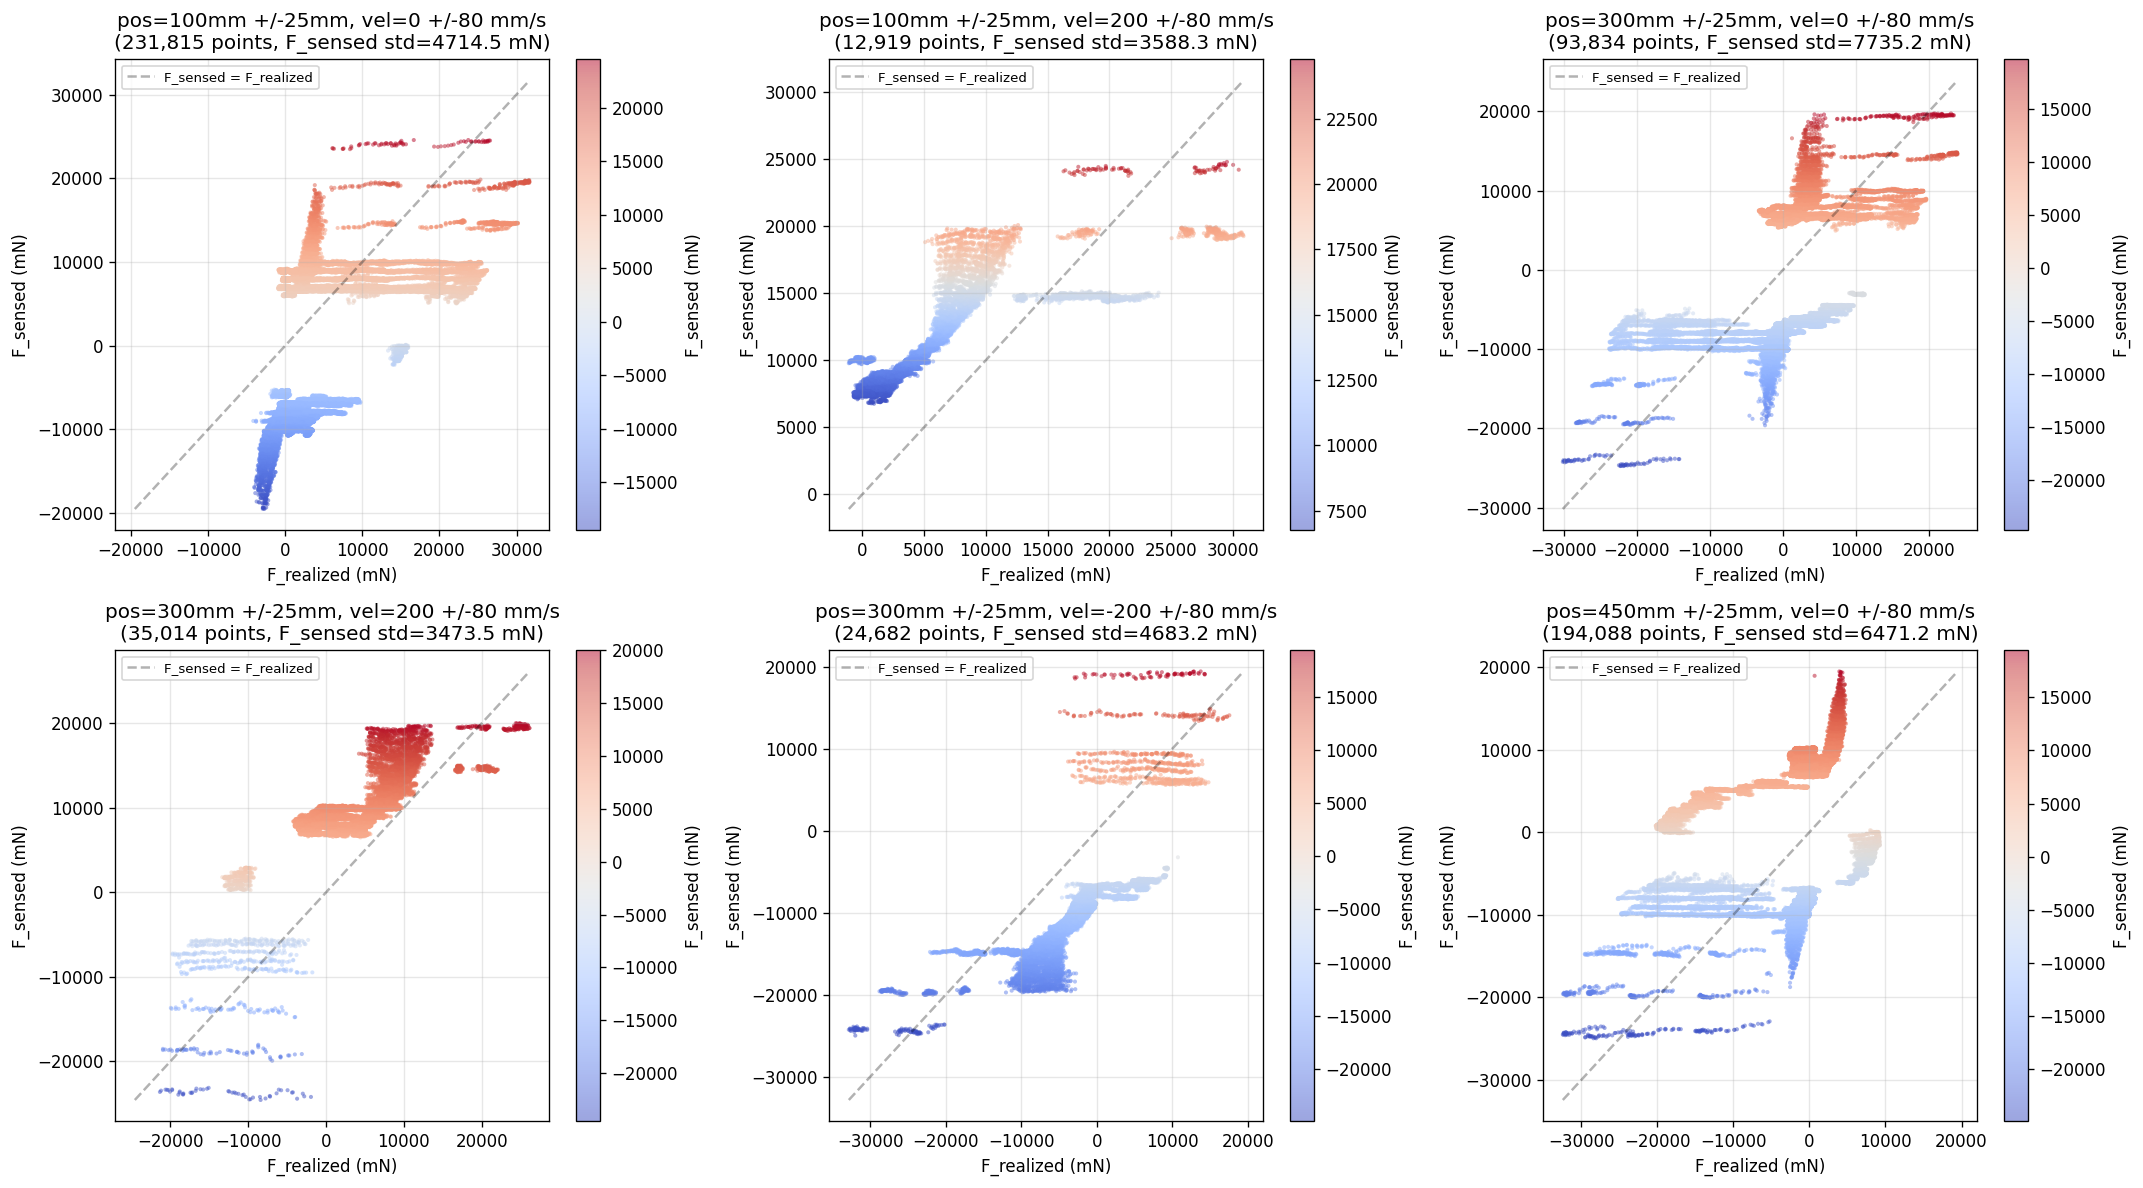


Summary:
 pos(mm)    vel    n_pts  F_s std     R²  resid std
     100      0  231,815   4714.5  0.335     3845.8
     100    200   12,919   3588.3  0.678     2037.7
     300      0   93,834   7735.2  0.080     7420.1
     300    200   35,014   3473.5  0.533     2374.5
     300   -200   24,682   4683.2  0.612     2917.5
     450      0  194,088   6471.2  0.058     6279.9


In [4]:
# Example: pick a few canonical points across the position range
canonical_points = [
    (100000, 0),    # near binding end, near zero velocity
    (100000, 200),  # near binding end, moderate positive velocity
    (300000, 0),    # mid-shaft, near zero velocity
    (300000, 200),  # mid-shaft, moderate positive velocity
    (300000, -200), # mid-shaft, moderate negative velocity
    (450000, 0),    # far end, near zero velocity
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
results = []
for ax, (cp, cv) in zip(axes.flat, canonical_points):
    r = plot_neighborhood(cp, cv, pos_radius_um=25000, vel_radius_mm_s=80, ax=ax)
    if r:
        results.append({"pos_um": cp, "vel_mm_s": cv, **r})
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"{'pos(mm)':>8} {'vel':>6} {'n_pts':>8} {'F_s std':>8} {'R²':>6} {'resid std':>10}")
for r in results:
    print(f"{r['pos_um']/1000:8.0f} {r['vel_mm_s']:6.0f} {r['n_points']:8,} "
          f"{r['f_sensed_std']:8.1f} {r['r_squared']:6.3f} {r['residual_std']:10.1f}")

## 2. Residual std after F_realized: how much target variance remains?

For each cell in a (position, velocity) grid, we fit `F_sensed ~ F_realized`
and compute the residual standard deviation. This tells us: given position,
velocity, and F_realized, how much unpredictable spread remains in F_sensed?

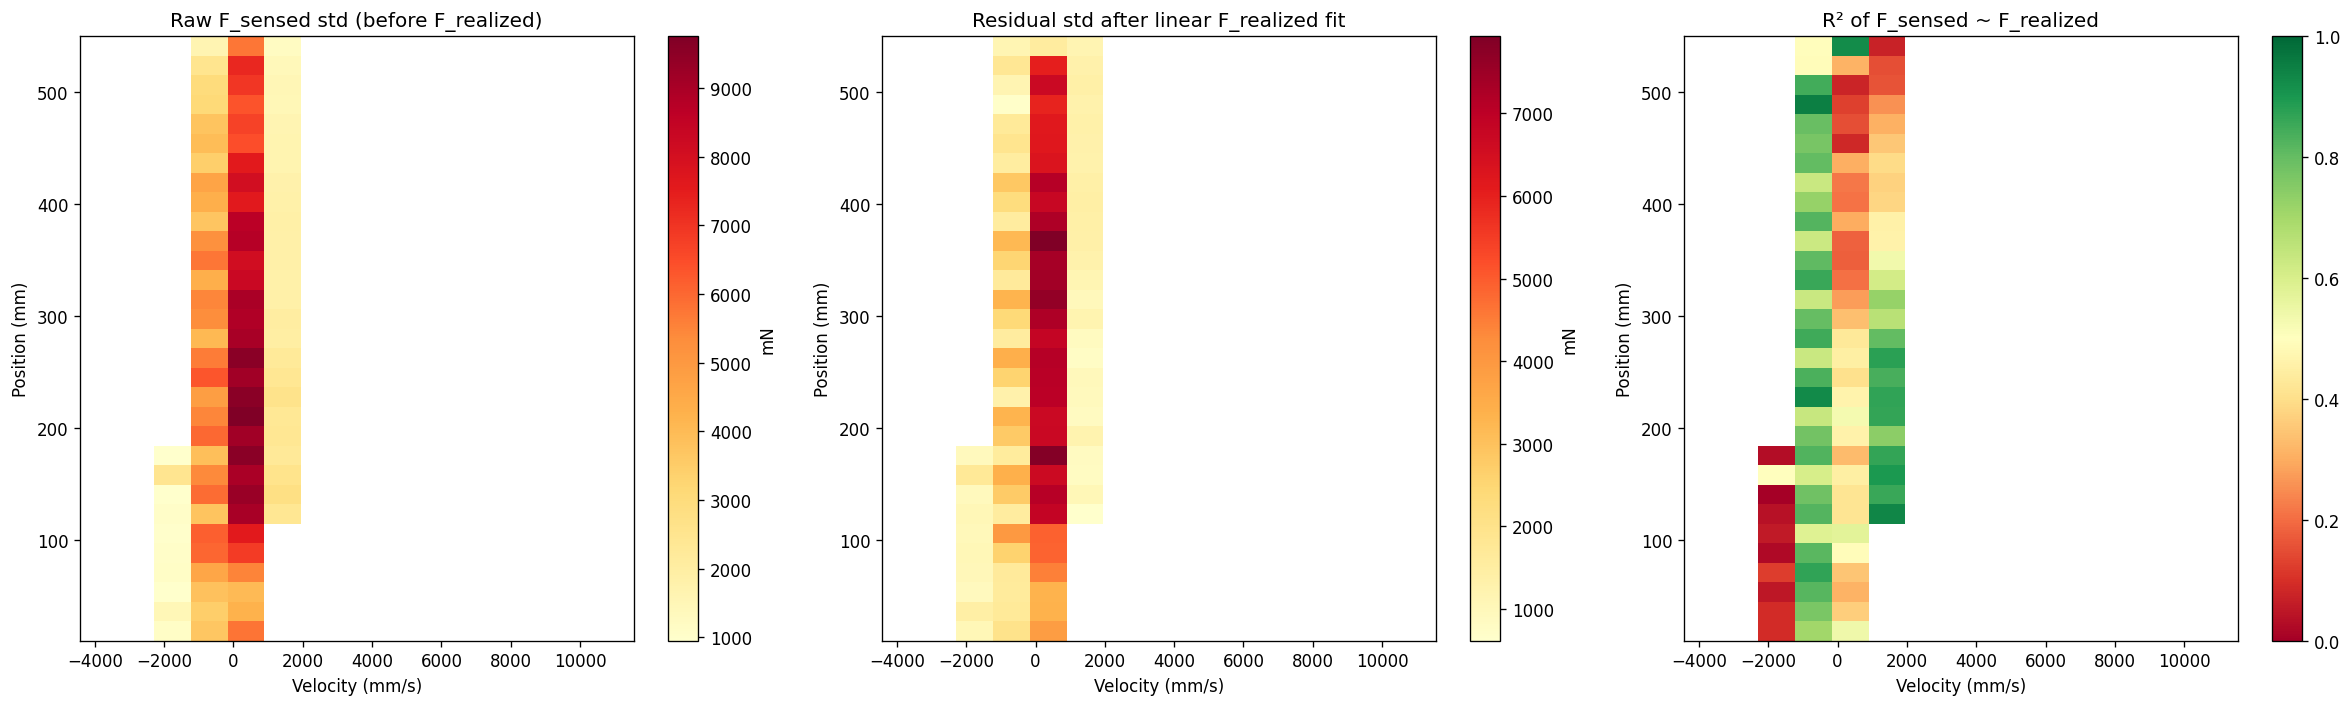

Cells with >= 30 points: 97 / 465
Median raw F_sensed std:     4030.4 mN
Median residual std:         1693.9 mN
Median R²:                   0.493
Variance explained by F_realized (median): 82.3%


In [6]:
def gridded_residual_analysis(n_pos_bins=31, n_vel_bins=15, min_pts=30):
    """For each (pos, vel) bin, fit F_sensed ~ F_realized and report residual std."""
    pos_edges = np.linspace(position.min(), position.max(), n_pos_bins + 1)
    vel_edges = np.linspace(velocity.min(), velocity.max(), n_vel_bins + 1)

    raw_std_grid = np.full((n_pos_bins, n_vel_bins), np.nan)
    resid_std_grid = np.full((n_pos_bins, n_vel_bins), np.nan)
    r2_grid = np.full((n_pos_bins, n_vel_bins), np.nan)
    count_grid = np.zeros((n_pos_bins, n_vel_bins), dtype=int)

    for i in range(n_pos_bins):
        for j in range(n_vel_bins):
            mask = (
                (position >= pos_edges[i]) & (position < pos_edges[i + 1]) &
                (velocity >= vel_edges[j]) & (velocity < vel_edges[j + 1])
            )
            n = mask.sum()
            count_grid[i, j] = n
            if n < min_pts:
                continue

            fs = f_sensed[mask]
            fr = f_realized[mask]
            raw_std_grid[i, j] = fs.std()

            slope, intercept, r, _, _ = linregress(fr, fs)
            resid = fs - (slope * fr + intercept)
            resid_std_grid[i, j] = resid.std()
            r2_grid[i, j] = r ** 2

    pos_centers = 0.5 * (pos_edges[:-1] + pos_edges[1:]) / 1000  # mm
    vel_centers = 0.5 * (vel_edges[:-1] + vel_edges[1:])

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    im0 = axes[0].pcolormesh(vel_centers, pos_centers, raw_std_grid,
                             cmap="YlOrRd", shading="nearest")
    plt.colorbar(im0, ax=axes[0], label="mN")
    axes[0].set_title("Raw F_sensed std (before F_realized)")
    axes[0].set_xlabel("Velocity (mm/s)")
    axes[0].set_ylabel("Position (mm)")

    im1 = axes[1].pcolormesh(vel_centers, pos_centers, resid_std_grid,
                             cmap="YlOrRd", shading="nearest")
    plt.colorbar(im1, ax=axes[1], label="mN")
    axes[1].set_title("Residual std after linear F_realized fit")
    axes[1].set_xlabel("Velocity (mm/s)")
    axes[1].set_ylabel("Position (mm)")

    im2 = axes[2].pcolormesh(vel_centers, pos_centers, r2_grid,
                             cmap="RdYlGn", shading="nearest",
                             vmin=0, vmax=1)
    plt.colorbar(im2, ax=axes[2])
    axes[2].set_title("R² of F_sensed ~ F_realized")
    axes[2].set_xlabel("Velocity (mm/s)")
    axes[2].set_ylabel("Position (mm)")

    plt.tight_layout()
    plt.show()

    valid = ~np.isnan(resid_std_grid)
    print(f"Cells with >= {min_pts} points: {valid.sum()} / {n_pos_bins * n_vel_bins}")
    print(f"Median raw F_sensed std:     {np.nanmedian(raw_std_grid):.1f} mN")
    print(f"Median residual std:         {np.nanmedian(resid_std_grid):.1f} mN")
    print(f"Median R²:                   {np.nanmedian(r2_grid):.3f}")
    print(f"Variance explained by F_realized (median): "
          f"{(1 - (np.nanmedian(resid_std_grid)/np.nanmedian(raw_std_grid))**2)*100:.1f}%")

    return raw_std_grid, resid_std_grid, r2_grid, count_grid

raw_std, resid_std, r2, counts = gridded_residual_analysis()

## 3. KNN target consistency

For a random subset of data, find each point's K nearest neighbors in the
normalized (position, velocity, F_realized) input space and compute the
standard deviation of F_sensed among those neighbors. Points with high
neighbor-target-spread are hard for any model to fit.

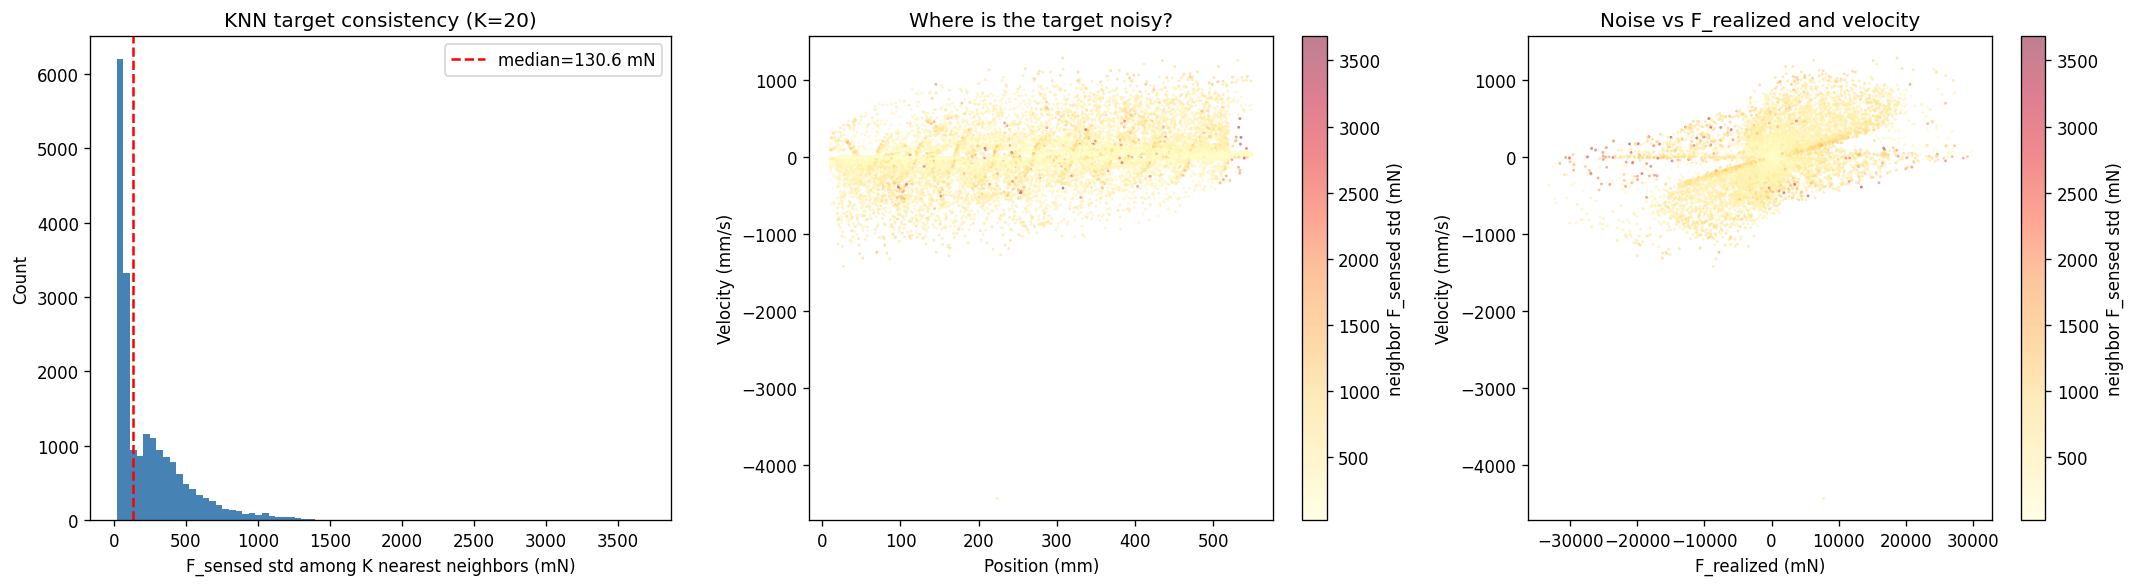

Neighbor F_sensed std percentiles (mN):
  25th: 60.2  50th: 130.6  75th: 366.6  90th: 612.5  95th: 813.8
Mean neighbor range (max-min): 932.7 mN


In [16]:
def knn_target_consistency(k=20, n_query=20000, seed=42):
    """Compute per-point F_sensed spread among K nearest input-space neighbors.
    Included f_sensed_prev in this"""
    rng = np.random.RandomState(seed)

    # z-score normalize inputs so distance is meaningful
    pos_z = (position - position.mean()) / position.std()
    vel_z = (velocity - velocity.mean()) / max(velocity.std(), 1e-9)
    fr_z = (f_realized - f_realized.mean()) / max(f_realized.std(), 1e-9)
    fs_prev_z = (f_sensed_prev - f_sensed_prev.mean()) / max(f_sensed_prev.std(), 1e-9)
    X = np.column_stack([pos_z, vel_z, fr_z, fs_prev_z])

    # subsample for speed (building tree on full data, querying a subset)
    n_total = len(X)
    tree_idx = rng.choice(n_total, size=min(200000, n_total), replace=False)
    tree = cKDTree(X[tree_idx])
    fs_tree = f_sensed[tree_idx]

    query_idx = rng.choice(n_total, size=min(n_query, n_total), replace=False)
    _, nn_idx = tree.query(X[query_idx], k=k)

    neighbor_fs = fs_tree[nn_idx]  # (n_query, k)
    neighbor_std = neighbor_fs.std(axis=1)
    neighbor_range = neighbor_fs.max(axis=1) - neighbor_fs.min(axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(neighbor_std, bins=80, color="steelblue", edgecolor="none")
    axes[0].axvline(np.median(neighbor_std), color="red", ls="--",
                    label=f"median={np.median(neighbor_std):.1f} mN")
    axes[0].set_xlabel("F_sensed std among K nearest neighbors (mN)")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"KNN target consistency (K={k})")
    axes[0].legend()

    # scatter: color points by their neighbor spread
    sc = axes[1].scatter(position[query_idx] / 1000, velocity[query_idx],
                         c=neighbor_std, cmap="YlOrRd", s=3, alpha=0.5,
                         edgecolors="none")
    plt.colorbar(sc, ax=axes[1], label="neighbor F_sensed std (mN)")
    axes[1].set_xlabel("Position (mm)")
    axes[1].set_ylabel("Velocity (mm/s)")
    axes[1].set_title("Where is the target noisy?")

    sc2 = axes[2].scatter(f_realized[query_idx], velocity[query_idx],
                          c=neighbor_std, cmap="YlOrRd", s=3, alpha=0.5,
                          edgecolors="none")
    plt.colorbar(sc2, ax=axes[2], label="neighbor F_sensed std (mN)")
    axes[2].set_xlabel("F_realized (mN)")
    axes[2].set_ylabel("Velocity (mm/s)")
    axes[2].set_title("Noise vs F_realized and velocity")

    plt.tight_layout()
    plt.show()

    pcts = np.percentile(neighbor_std, [25, 50, 75, 90, 95])
    print(f"Neighbor F_sensed std percentiles (mN):")
    print(f"  25th: {pcts[0]:.1f}  50th: {pcts[1]:.1f}  75th: {pcts[2]:.1f}  "
          f"90th: {pcts[3]:.1f}  95th: {pcts[4]:.1f}")
    print(f"Mean neighbor range (max-min): {neighbor_range.mean():.1f} mN")

    return neighbor_std, query_idx

neighbor_std, query_idx = knn_target_consistency(k=20)

## 4. Binned ambiguity: identical-input, different-output detection

Discretize the 3D input space into fine bins. For each bin with enough points,
compute the F_sensed spread. Bins with high spread are truly ambiguous — the
same inputs produce different outputs, and no model can resolve this.

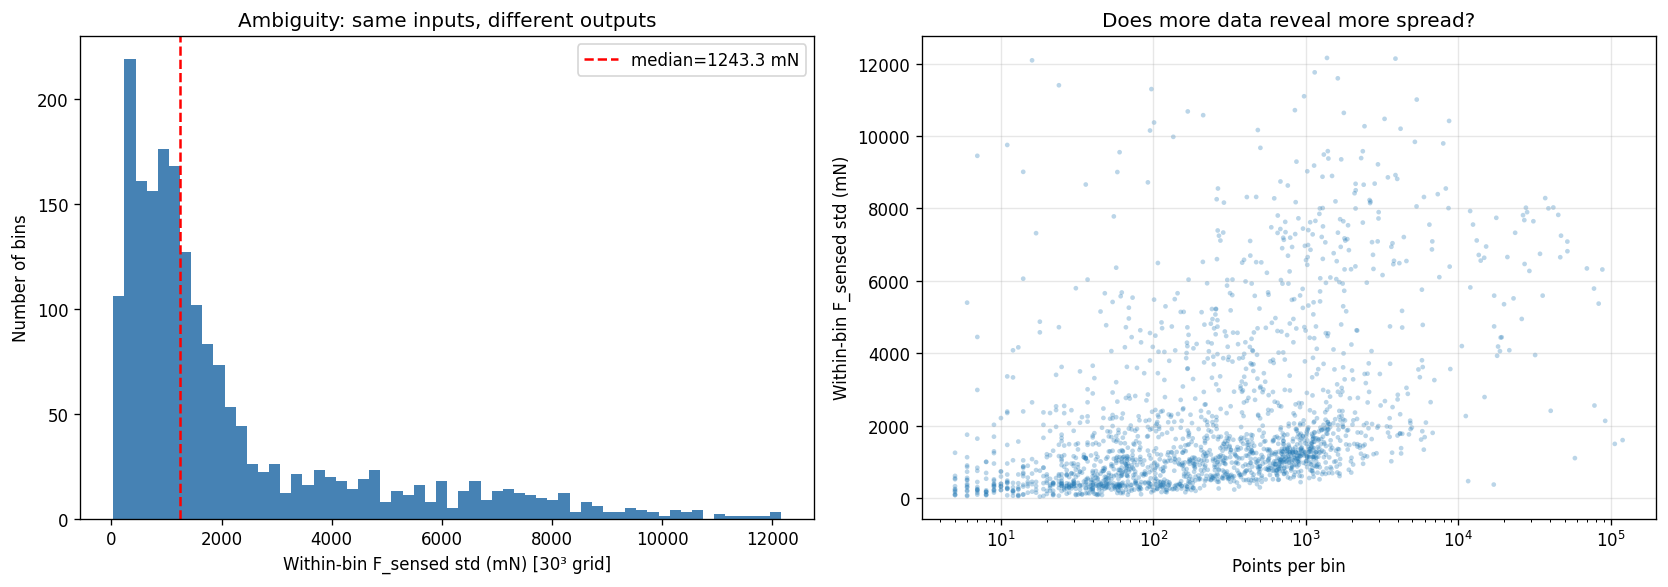

Occupied bins with >= 5 points: 1964
Within-bin F_sensed std percentiles (mN):
  25th: 647.3  50th: 1243.3  75th: 2526.1  90th: 5924.2  95th: 7500.9

If the median within-bin std is small relative to the overall 
F_sensed std (10072.9 mN), the inputs are informative.
Ratio (median bin std / global std): 0.123


In [8]:
def binned_ambiguity(n_bins=30, min_pts=5):
    """Bin the 3D input space and compute within-bin F_sensed statistics."""
    pos_edges = np.linspace(position.min(), position.max(), n_bins + 1)
    vel_edges = np.linspace(velocity.min(), velocity.max(), n_bins + 1)
    fr_edges = np.linspace(f_realized.min(), f_realized.max(), n_bins + 1)

    pos_bin = np.digitize(position, pos_edges) - 1
    vel_bin = np.digitize(velocity, vel_edges) - 1
    fr_bin = np.digitize(f_realized, fr_edges) - 1

    pos_bin = np.clip(pos_bin, 0, n_bins - 1)
    vel_bin = np.clip(vel_bin, 0, n_bins - 1)
    fr_bin = np.clip(fr_bin, 0, n_bins - 1)

    flat_idx = pos_bin * n_bins * n_bins + vel_bin * n_bins + fr_bin

    unique_bins, inverse = np.unique(flat_idx, return_inverse=True)

    bin_stds = []
    bin_counts = []
    bin_means = []
    for i, b in enumerate(unique_bins):
        members = f_sensed[inverse == i]
        if len(members) >= min_pts:
            bin_stds.append(members.std())
            bin_counts.append(len(members))
            bin_means.append(members.mean())

    bin_stds = np.array(bin_stds)
    bin_counts = np.array(bin_counts)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(bin_stds, bins=60, color="steelblue", edgecolor="none")
    axes[0].axvline(np.median(bin_stds), color="red", ls="--",
                    label=f"median={np.median(bin_stds):.1f} mN")
    axes[0].set_xlabel(f"Within-bin F_sensed std (mN) [{n_bins}³ grid]")
    axes[0].set_ylabel("Number of bins")
    axes[0].set_title("Ambiguity: same inputs, different outputs")
    axes[0].legend()

    axes[1].scatter(bin_counts, bin_stds, s=8, alpha=0.3, edgecolors="none")
    axes[1].set_xlabel("Points per bin")
    axes[1].set_ylabel("Within-bin F_sensed std (mN)")
    axes[1].set_title("Does more data reveal more spread?")
    axes[1].set_xscale("log")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    pcts = np.percentile(bin_stds, [25, 50, 75, 90, 95])
    print(f"Occupied bins with >= {min_pts} points: {len(bin_stds)}")
    print(f"Within-bin F_sensed std percentiles (mN):")
    print(f"  25th: {pcts[0]:.1f}  50th: {pcts[1]:.1f}  75th: {pcts[2]:.1f}  "
          f"90th: {pcts[3]:.1f}  95th: {pcts[4]:.1f}")
    print(f"\nIf the median within-bin std is small relative to the overall ")
    print(f"F_sensed std ({f_sensed.std():.1f} mN), the inputs are informative.")
    print(f"Ratio (median bin std / global std): {np.median(bin_stds) / f_sensed.std():.3f}")

    return bin_stds, bin_counts

bin_stds, bin_counts = binned_ambiguity(n_bins=30)

## 5. Does adding previous-timestep features reduce ambiguity?

Compare the KNN target spread using just (pos, vel, F_realized) vs.
expanded feature sets that include lagged variables.

In [9]:
# Load lagged features (train only for speed)
train_pos = d["train_position_um_aligned"]
train_vel = d["train_velocity_mm_s_aligned"]
train_fr = d["train_force_mN_realized_aligned"]
train_fs = d["train_force_mN_sensed_aligned"]

lagged_keys = ["train_accel_mmpss_prev", "train_velocity_mm_s_prev",
               "train_position_um_prev", "train_force_mN_sensed_prev"]
has_lagged = all(k in d for k in lagged_keys)

if has_lagged:
    train_accel_prev = d["train_accel_mmpss_prev"]
    train_vel_prev = d["train_velocity_mm_s_prev"]
    train_pos_prev = d["train_position_um_prev"]
    train_fs_prev = d["train_force_mN_sensed_prev"]
    print(f"Lagged features available. Train samples: {len(train_pos):,}")
else:
    print("Lagged features not found in dataset — skipping Model 2/3/4 comparison.")

Lagged features available. Train samples: 2,269,817


/var/folders/t_/825svyys2wv0k4ts6p2_b5lw0000gn/T/ipykernel_75326/1781955707.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True)


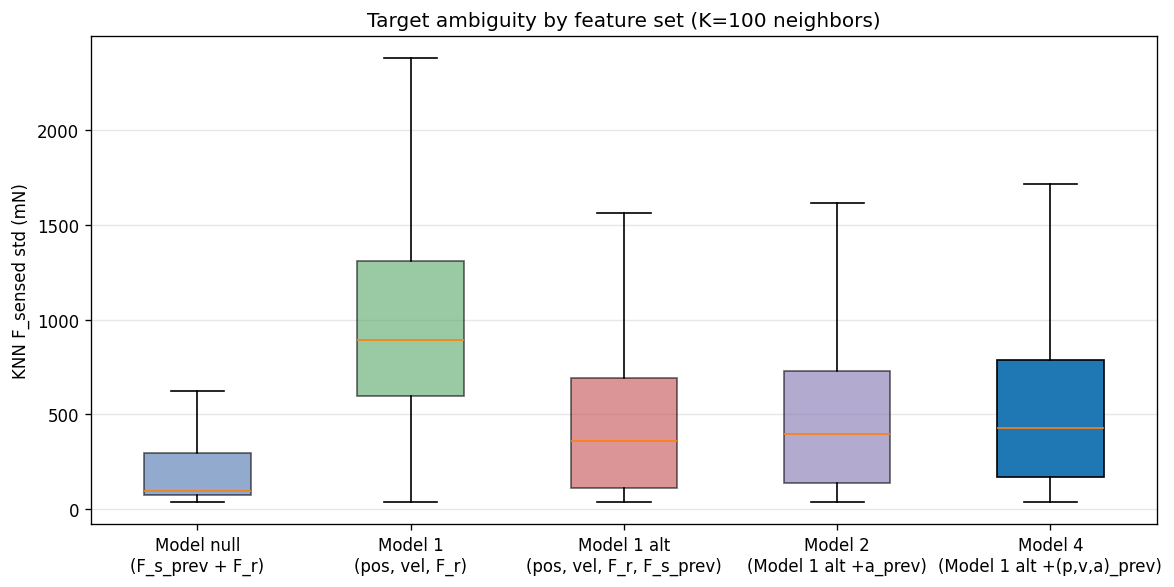

Feature set                         median std   90th pct
Model null (F_s_prev + F_r)               97.1      516.6
Model 1 (pos, vel, F_r)                  892.3     2744.3
Model 1 alt (pos, vel, F_r, F_s_prev)      359.6     1049.2
Model 2 (Model 1 alt +a_prev)            394.2     1095.3
Model 4 (Model 1 alt +(p,v,a)_prev)      430.2     1176.4


In [ ]:
def compare_feature_sets(n_query=15000, k=100, seed=42):
    """Compare KNN target consistency across different model features."""
    if not has_lagged:
        print("Skipped: no lagged features.")
        return

    rng = np.random.RandomState(seed)
    n = len(train_pos)
    sub = min(150000, n)
    tree_idx = rng.choice(n, size=sub, replace=False)
    query_idx = rng.choice(n, size=min(n_query, n), replace=False)

    def z(arr):
        s = arr.std()
        return (arr - arr.mean()) / (s if s > 1e-9 else 1.0)

    feature_sets = {
        "Model null\n(F_s_prev + F_r)":np.column_stack([z(train_fs_prev), z(train_fr)]),
        "Model 1\n(pos, vel, F_r)": np.column_stack([
            z(train_pos), z(train_vel), z(train_fr)]),
        "Model 1 alt\n(pos, vel, F_r, F_s_prev)": np.column_stack([
            z(train_pos), z(train_vel), z(train_fr), z(train_fs_prev)]),
        "Model 2\n(Model 1 alt +a_prev)": np.column_stack([
            z(train_pos), z(train_vel), z(train_fr), z(train_fs_prev), z(train_accel_prev)]),
        "Model 4\n(Model 1 alt +(p,v,a)_prev)": np.column_stack([
            z(train_pos), z(train_vel), z(train_fr), z(train_fs_prev),
            z(train_accel_prev), z(train_pos_prev), z(train_vel_prev)]),

    }

    results = {}
    for name, X in feature_sets.items():
        tree = cKDTree(X[tree_idx])
        _, nn = tree.query(X[query_idx], k=k)
        nn_fs = train_fs[tree_idx][nn]
        stds = nn_fs.std(axis=1)
        results[name] = stds

    fig, ax = plt.subplots(figsize=(10, 5))
    data = [results[k] for k in results]
    labels = list(results.keys())
    bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True)
    colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_ylabel("KNN F_sensed std (mN)")
    ax.set_title(f"Target ambiguity by feature set (K={k} neighbors)")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    print(f"{'Feature set':<35} {'median std':>10} {'90th pct':>10}")
    for name, stds in results.items():
        name_flat = name.replace('\n', ' ')
        print(f"{name_flat:<35} {np.median(stds):10.1f} {np.percentile(stds, 90):10.1f}")

compare_feature_sets()

Comment: well obviously the previous F_sensed value is going to be related to the next F_sensed value because they're so correlated given my training data (constant force commands, or constant commands that switch at particular points). I want to figure out what force command will produce the desired acceleration at across the shaft (so at a particular position and velocity), so acceleration needs to be in the input.

In the inverse case: how similar are F_realized values for neighborhoods of F_sensed, position, velocity?

/var/folders/t_/825svyys2wv0k4ts6p2_b5lw0000gn/T/ipykernel_75326/474754694.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True)


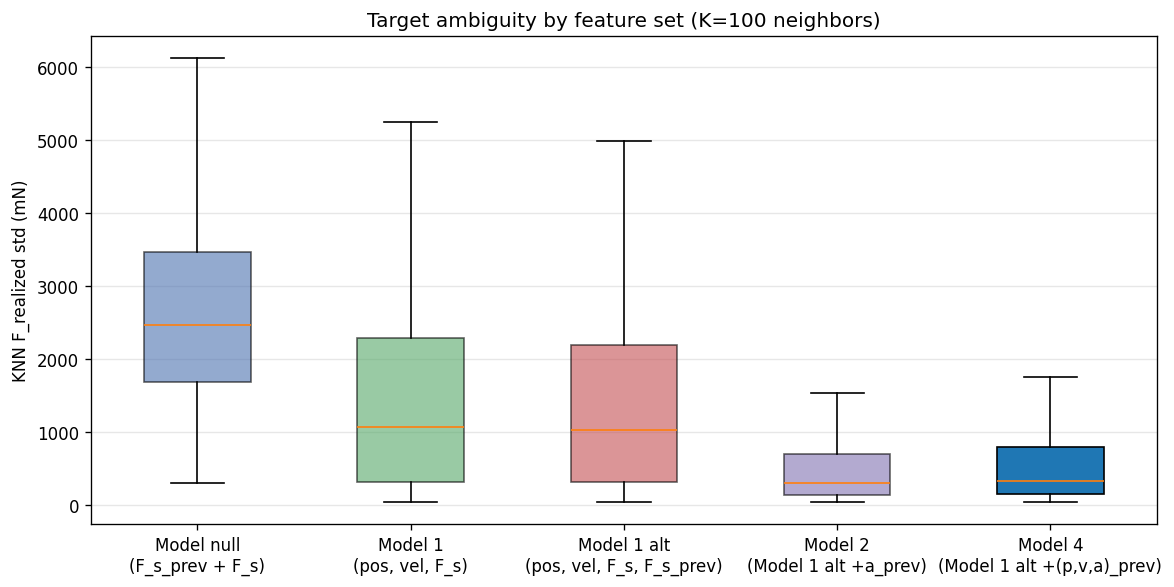

Feature set                         median std   90th pct
Model null (F_s_prev + F_s)             2474.0     4572.2
Model 1 (pos, vel, F_s)                 1069.8     3683.4
Model 1 alt (pos, vel, F_s, F_s_prev)     1030.0     3593.3
Model 2 (Model 1 alt +a_prev)            298.2     1041.3
Model 4 (Model 1 alt +(p,v,a)_prev)      329.8     1184.2


In [20]:
def compare_feature_sets_inverse(n_query=15000, k=100, seed=42):
    """Compare KNN target consistency across different model features for the inverse prediction (predicting F_realized)"""
    if not has_lagged:
        print("Skipped: no lagged features.")
        return

    rng = np.random.RandomState(seed)
    n = len(train_pos)
    sub = min(150000, n)
    tree_idx = rng.choice(n, size=sub, replace=False)
    query_idx = rng.choice(n, size=min(n_query, n), replace=False)

    def z(arr):
        s = arr.std()
        return (arr - arr.mean()) / (s if s > 1e-9 else 1.0)

    feature_sets = {
        "Model null\n(F_s_prev + F_s)": np.column_stack([z(train_fs), z(train_fs_prev)]),
        "Model 1\n(pos, vel, F_s)": np.column_stack([
            z(train_pos), z(train_vel), z(train_fs)]),
        "Model 1 alt\n(pos, vel, F_s, F_s_prev)": np.column_stack([
            z(train_pos), z(train_vel), z(train_fs), z(train_fs_prev)]),
        "Model 2\n(Model 1 alt +a_prev)": np.column_stack([
            z(train_pos), z(train_vel), z(train_fs), z(train_fs_prev), z(train_accel_prev)]),
        "Model 4\n(Model 1 alt +(p,v,a)_prev)": np.column_stack([
            z(train_pos), z(train_vel), z(train_fs), z(train_fs_prev),
            z(train_accel_prev), z(train_pos_prev), z(train_vel_prev)]),

    }

    results = {}
    for name, X in feature_sets.items():
        tree = cKDTree(X[tree_idx])
        _, nn = tree.query(X[query_idx], k=k)
        nn_fr = train_fr[tree_idx][nn]
        stds = nn_fr.std(axis=1)
        results[name] = stds

    fig, ax = plt.subplots(figsize=(10, 5))
    data = [results[k] for k in results]
    labels = list(results.keys())
    bp = ax.boxplot(data, labels=labels, showfliers=False, patch_artist=True)
    colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_ylabel("KNN F_realized std (mN)")
    ax.set_title(f"Target ambiguity by feature set (K={k} neighbors)")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    print(f"{'Feature set':<35} {'median std':>10} {'90th pct':>10}")
    for name, stds in results.items():
        name_flat = name.replace('\n', ' ')
        print(f"{name_flat:<35} {np.median(stds):10.1f} {np.percentile(stds, 90):10.1f}")

compare_feature_sets_inverse()

Related comment: from looking at potential inverse models (using inputs to try to predict what the realize force will be), it makes sense that adding information about the previous acceleration value is highly correlated with the F_realized value. I will collect more data on varying the force command sinusoidally (which is similar to what will happen in the simulation) to see if those outputs change my results

## 6. F_sensed vs F_realized global relationship

Simple overall view: how close is F_sensed to F_realized across the full
dataset? The residual `F_sensed - F_realized` is essentially the friction
force the MLP needs to learn.

In [ ]:
residual = f_sensed - f_realized

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2D histogram: F_realized vs F_sensed
axes[0].hist2d(f_realized, f_sensed, bins=150, cmap="viridis",
               norm=plt.matplotlib.colors.LogNorm())
lims = [min(f_realized.min(), f_sensed.min()),
        max(f_realized.max(), f_sensed.max())]
axes[0].plot(lims, lims, "r--", alpha=0.5)
axes[0].set_xlabel("F_realized (mN)")
axes[0].set_ylabel("F_sensed (mN)")
axes[0].set_title("F_sensed vs F_realized (log density)")

# Residual histogram
axes[1].hist(residual, bins=150, color="steelblue", edgecolor="none")
axes[1].axvline(0, color="red", ls="--")
axes[1].set_xlabel("F_sensed - F_realized (mN)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Friction residual\nmean={residual.mean():.1f}, std={residual.std():.1f} mN")

# Residual vs velocity (friction's primary dependence)
step = max(1, len(residual) // 30000)
sc = axes[2].scatter(velocity[::step], residual[::step],
                     c=position[::step] / 1000, cmap="viridis",
                     s=3, alpha=0.3, edgecolors="none")
plt.colorbar(sc, ax=axes[2], label="Position (mm)")
axes[2].set_xlabel("Velocity (mm/s)")
axes[2].set_ylabel("F_sensed - F_realized (mN)")
axes[2].set_title("Friction residual vs velocity, colored by position")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Interactive neighborhood explorer

Change `CANONICAL_POS` and `CANONICAL_VEL` below to explore any point
in the input space. Adjust the radii to widen/narrow the neighborhood.

In [ ]:
CANONICAL_POS = 120000   # um
CANONICAL_VEL = 0      # mm/s
POS_RADIUS    = 20000    # um
VEL_RADIUS    = 50       # mm/s

fig, ax = plt.subplots(figsize=(9, 6))
stats = plot_neighborhood(CANONICAL_POS, CANONICAL_VEL,
                          pos_radius_um=POS_RADIUS,
                          vel_radius_mm_s=VEL_RADIUS, ax=ax)
plt.show()

if stats:
    print(f"\nR² of F_realized -> F_sensed: {stats['r_squared']:.4f}")
    print(f"Residual std after linear fit: {stats['residual_std']:.1f} mN")
    print(f"Raw F_sensed std: {stats['f_sensed_std']:.1f} mN")
    frac = 1 - (stats['residual_std'] / stats['f_sensed_std'])**2 if stats['f_sensed_std'] > 0 else 0
    print(f"Variance explained by F_realized: {frac*100:.1f}%")
    print(f"\nRemaining {stats['residual_std']:.1f} mN residual std is the "
          f"irreducible noise floor for Model 1 in this region ")
    print(f"(unless position/velocity provide additional structure within the bin).")